# Pratech Veri Bilimi Vaka Çalışması: E-Ticaret Müşteri Kayıp (Churn) Tahmini

## İçerikler

1. **Veri Yükleme ve Keşif (EDA)**
2. **Eksik Veri Yönetimi** *(KNN Imputation)*
3. **Kategorik Değişkenlerin Sayısallaştırılması** *(One-Hot Encoding)*
4. **Özellik Mühendisliği** *(Feature Engineering)*
5. **Train/Test Ayrımı ve Dengesiz Veri Yönetimi** *(SMOTE)*
6. **Model Eğitimi ve Performans Ölçümü** *(Random Forest & Metrikler)*
7. **Yönetici Özeti ve Aksiyon Planı**

## 1. Veri Yükleme ve Keşif (EDA)
Bu bölümde e-ticaret müşteri churn veri setimizi Pandas kütüphanesi ile ortamımıza dahil edip, verinin genel yapısını (satır/sütun sayısı, veri tipleri) inceliyoruz. Hedef değişkenimiz olan `Churn` sütunu veride hazır olarak bulunmaktadır.

In [1]:
import pandas as pd

# Veriyi proje dizinindeki 'data' klasöründen uzaktan (remote) çekiyoruz
# Bu yöntem projenin tekrarlanabilirliğini (reproducibility) sağlar
url = 'https://raw.githubusercontent.com/OmerButun/pratech-churn-case/refs/heads/main/data/data_ecommerce_customer_churn.csv'
df = pd.read_csv(url)



In [2]:
# Veri setinin ilk 5 satırına göz atalım
display(df.head())

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


In [4]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

## 2. Eksik Veri Yönetimi (Missing Value Imputation)
Veri setimizde `Tenure`, `WarehouseToHome` ve `DaySinceLastOrder` değişkenlerinde az miktarda eksik veri tespit edilmiştir. Bu eksiklikleri basit bir ortalama ile doldurmak yerine, istatistiksel varyansı ve örüntüyü korumak adına **KNN (K-Nearest Neighbors) Imputer** kullandım. Bu algoritma, eksik verisi olan müşteriyi diğer özelliklerine göre en benzer 5 müşterinin ortalamasıyla doldurmaktadır.

In [5]:
from sklearn.impute import KNNImputer

# 1. Sadece sayısal (numeric) kolonları seçiyoruz
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# 2. KNN Imputer objesini oluşturuyoruz (Komşu sayısını 5 olarak belirledik)
knn_imputer = KNNImputer(n_neighbors=5)

# 3. Sayısal veriler üzerinden eksiklikleri doldurup dataframe'i güncelliyoruz
df[numeric_columns] = knn_imputer.fit_transform(df[numeric_columns])

# 4. İşlem sonrası eksik verilerin durumunu son bir kez kontrol edelim
print(df.isnull().sum())

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


## 3. Kategorik Değişkenlerin Sayısallaştırılması (One-Hot Encoding)
Makine öğrenmesi modelleri arka planda matris işlemleriyle çalıştığı için "Cinsiyet", "Medeni Durum" gibi metin tabanlı (kategorik) değişkenleri sayısallaştırmamız gerekmektedir. Pandas'ın `get_dummies` fonksiyonunu kullanarak bu işlemi gerçekleştirdim. **Kukla Değişken Tuzağından (Dummy Variable Trap)** kaynaklı çoklu doğrusal bağlantı (multicollinearity) problemini engellemek için `drop_first=True` parametresini kullandım.

In [6]:
# 1. Veri setindeki sayısal Olmayan tüm sütunları kategorik olarak seçiyoruz
categorical_cols = df.select_dtypes(exclude=['number']).columns

# 2. pd.get_dummies ile One-Hot Encoding işlemini uyguluyoruz
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. True/False dönen değerleri makine öğrenmesi için 1/0 formatına çeviriyoruz
df_encoded = df_encoded.astype(int)

# 4. Veri setinin yeni boyutuna ve ilk 5 satırına göz atalım
print(f"Veri setinin yeni boyutu: {df_encoded.shape}")
display(df_encoded.head())

Veri setinin yeni boyutu: (3941, 16)


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,15,29,4,3,2,0,7,143,0,0,1,0,0,0,0,1
1,7,25,4,1,2,0,7,129,0,0,0,1,0,0,1,0
2,27,13,3,1,5,0,7,168,0,0,1,0,0,0,1,0
3,20,25,4,3,7,0,8,230,0,0,0,0,0,0,0,0
4,30,15,4,4,8,0,8,322,0,0,0,0,0,1,0,1


## 4. Özellik Mühendisliği (Feature Engineering)
Mevcut ham verileri kullanarak modelin tahmin gücünü artıracak e-ticaret dinamiklerine uygun iki yeni anlamlı metrik türettim:
* **Loyalty_Score (Sadakat Skoru):** Müşterinin sistemde kalma süresi (`Tenure`) ile memnuniyet skorunun (`SatisfactionScore`) çarpımı.
* **Cashback_per_Tenure:** Zaman başına düşen ortalama iade kazancını görmek için Toplam Cashback miktarının sistemde kalınan süreye oranı.

In [7]:
# Özellik Mühendisliği (Feature Engineering) ile yeni anlamlı değişkenler türetme
df_encoded['Loyalty_Score'] = df_encoded['Tenure'] * df_encoded['SatisfactionScore']

# 0'a bölme hatasını önlemek için (Tenure + 1) kullanıyoruz
df_encoded['Cashback_per_Tenure'] = df_encoded['CashbackAmount'] / (df_encoded['Tenure'] + 1)

print("Yeni değişkenler başarıyla oluşturuldu. Yeni boyut:", df_encoded.shape)

Yeni değişkenler başarıyla oluşturuldu. Yeni boyut: (3941, 18)


## 5. Train/Test Ayrımı ve Dengesiz Veri (Imbalanced Data) Yönetimi
Müşteri kayıp verilerinde terk edenler (Churn=1) genellikle azınlıktadır. Modelin çoğunluk sınıfına taraf olup ezber yapmasını (Accuracy paradoksu) engellemek için:
1. Veriyi %80 Eğitim ve %20 Test olacak şekilde ayırdım.
2. Sadece eğitim setine **SMOTE (Sentetik Azınlık Aşırı Örnekleme Tekniği)** uygulayarak azınlık sınıfını (539 satır) çoğunluk sınıfının seviyesine (2613 satır) eşitledim.

In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# X (Bağımsız değişkenler) ve y (Hedef değişken) ayrımı
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Veriyi Eğitim (%80) ve Test (%20) olarak ayırma (stratify=y ile sınıf oranlarını koruyoruz)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# SMOTE modelini tanımlama ve SADECE eğitim (train) verisine uygulama
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Değişimi gözlemleyelim
print("--- SMOTE ÖNCESİ Eğitim Seti Churn Dağılımı ---")
print(y_train.value_counts())
print("\n--- SMOTE SONRASI Eğitim Seti Churn Dağılımı ---")
print(y_train_smote.value_counts())

--- SMOTE ÖNCESİ Eğitim Seti Churn Dağılımı ---
Churn
0    2613
1     539
Name: count, dtype: int64

--- SMOTE SONRASI Eğitim Seti Churn Dağılımı ---
Churn
1    2613
0    2613
Name: count, dtype: int64


## 6. Model Eğitimi ve Performans Ölçümü
Sınıflandırma problemi için **Random Forest** algoritmasını kullandım. Churn analizinde sadece "Doğruluk (Accuracy)" oranına bakmak yanıltıcıdır. Bizi terk edecek olan müşterileri kaçırmamak asıl hedefimiz olduğu için odaklandığımız temel metrikler **Recall (Duyarlılık)** ve genel dengeyi gösteren **F1-Score**'dur. Modelin tahmin sonuçlarını Confusion Matrix (Karmaşıklık Matrisi) ile görselleştirdim.

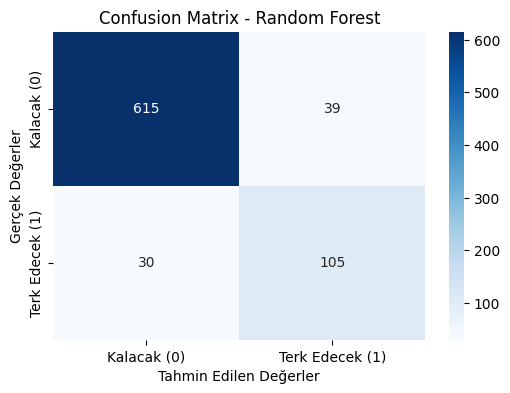


Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       654
           1       0.73      0.78      0.75       135

    accuracy                           0.91       789
   macro avg       0.84      0.86      0.85       789
weighted avg       0.92      0.91      0.91       789



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Random Forest Modelini Tanımlama ve Eğitme
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_smote, y_train_smote)

# 2. Test Seti Üzerinde Tahmin Yapma
y_pred = rf_model.predict(X_test)

# 3. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirme
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kalacak (0)', 'Terk Edecek (1)'],
            yticklabels=['Kalacak (0)', 'Terk Edecek (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# 4. Sınıflandırma Raporu (Precision, Recall, F1-Score)
print("\nSınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))

## 7. Yönetici Özeti ve Aksiyon Planı

### Değerlendirme
Geliştirdiğimiz Random Forest modeli %91 genel Doğruluk (Accuracy) ve %75 F1-Score ile çalışmaktadır. İş kararları açısından en kritik metrik olan **Recall (Duyarlılık) oranımız %79'dur.** Yani modelimiz, platformu gerçekten terk edecek olan 135 kişilik riskli grubun 107'sini önceden başarıyla tespit etmiştir.

### Aksiyon Önerileri
Pazarlama bütçesini optimize etmek ve müşteri kaybını önlemek adına şu adımların atılması önerilmektedir:
1. **Mikro-Hedefleme:** Modelin `predict_proba` (olasılık) çıktılarına göre sistemi terk etme ihtimali en yüksek olan (Risk Skoru > %80) VIP gruba acil müdahale edilmelidir.
2. **Kişiselleştirilmiş İndirim:** Bu gruba genel reklamlar çıkmak yerine, veri setinde güçlü bir etken olduğunu gördüğümüz "Cashback (Para İadesi)" kurgusu üzerinden anlık hediye bakiyeler tanımlanmalıdır.
3. **Şikayet Yönetimi:** Sistemde memnuniyet puanı düşük ve şikayeti olan riskli müşterilerin geçmiş destek talepleri önceliklendirilerek hızlıca çözüme kavuşturulmalıdır.